In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio      # βιβλιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)

## Άσκηση - Φίλτρα 1ης τάξης (βαθυπερατό / υψιπερατό / ζωνοπερατό)

Στην άσκηση αυτή μελετάμε την οικογένεια των **φίλτρων 1ης τάξης**, τα οποία λειτουργούν ως απλά ρυθμιστικά χροιάς (tone controls). Θα εξετάσουμε ένα βαθυπερατό (lowpass) και ένα υψιπερατό (highpass) σύστημα, και στη συνέχεια θα τα συνδυάσουμε σε σειρά για να κατασκευάσουμε ένα ζωνοπερατό (bandpass) φίλτρο. Κάθε σύστημα ελέγχεται από μία παράμετρο $\alpha$ (με $0 < \alpha < 1$), η οποία καθορίζει τη συχνότητα αποκοπής.

i. Θεωρήστε την παρακάτω εξίσωση διαφορών που περιγράφει ένα αιτιατό ΓΧΑ σύστημα
$$y[n] = (1-\alpha)\, x[n] + \alpha\, y[n-1], \: \: 0 < \alpha < 1 \ \  (1)$$

(α') Υπολογίστε στο χαρτί σας τη συνάρτηση μεταφοράς, $H(z)$, του παραπάνω συστήματος.

<u>**Απάντηση**</u>

Θα είναι:

$$y[n] = (1-\alpha) x[n] + \alpha y[n-1] \overset{Z}{\longleftrightarrow} Y(z) = (1-\alpha) X(z) + \alpha Y(z) z^{-1} \Rightarrow Y(z)\left(1 - \alpha z^{-1}\right) = (1-\alpha) X(z)$$

και άρα

$$H_{1}(z) = \frac{Y(z)}{X(z)} = \frac{1-\alpha}{1 - \alpha z^{-1}}$$

δηλαδή η συνάρτηση μεταφοράς έχει έναν πόλο στο σημείο $z = \alpha$ και ένα μηδενικό στο $z = 0$. Αφού $0 < \alpha < 1$, ο πόλος βρίσκεται εντός του μοναδιαίου κύκλου. Για να είναι το σύστημα αιτιατό, πρέπει $ROC_{H_{1}}: |z| > \alpha$. Παρατηρούμε ότι στο $\omega = 0$ ($z=1$) το κέρδος είναι $\frac{1-\alpha}{1-\alpha} = 1$, ενώ στο $\omega = \pi$ ($z=-1$) το κέρδος είναι $\frac{1-\alpha}{1+\alpha} \ll 1$: πρόκειται για **βαθυπερατό** φίλτρο. Έτσι,

$$H_{1}(z) = \frac{1-\alpha}{1 - \alpha z^{-1}}, \: |z|>\alpha$$

(β') Βρείτε στο χαρτί σας την κρουστική απόκριση $h[n]$.

<u>**Απάντηση**</u>

H κρουστική απόκριση είναι ο αντίστροφος μετασχηματισμός $Z$ της συνάρτησης μεταφοράς. Βάσει του γνωστού ζεύγους $\dfrac{1}{1 - \alpha z^{-1}} \overset{Z}{\longleftrightarrow} \alpha^{n} u[n]$ (για αιτιατό σύστημα, $|z|>\alpha$), προκύπτει:

$$h_{1}[n] = (1-\alpha)\, \alpha^{n}\, u[n]$$

δηλαδή μια **φθίνουσα εκθετική** ("leaky integrator"): όσο πιο κοντά στο $1$ είναι το $\alpha$, τόσο πιο αργά αποσβένεται και τόσο πιο έντονο είναι το βαθυπερατό φιλτράρισμα. Επαληθεύεται ότι $\sum_{n} h_{1}[n] = (1-\alpha)\frac{1}{1-\alpha} = 1$, δηλαδή κέρδος $1$ στο DC.

(γ') Υπολογίστε στο χαρτί σας την απόκριση σε συχνότητα, $H(e^{j\omega})$.

<u>**Απάντηση**</u>

Το πεδίο σύγκλισης $ROC_{H_{1}}: |z|>\alpha$ περιέχει τον μοναδιαίο κύκλο (αφού $\alpha<1$), άρα ορίζεται ο μετασχηματισμός Fourier μέσω του μετασχηματισμού $Z$:

$$H_{1}(e^{j\omega}) = H_{1}(z) \Big|_{z = e^{j\omega}} \Rightarrow H_{1}(e^{j\omega}) = \frac{1-\alpha}{1 - \alpha e^{-j\omega}}$$

Το μέτρο $|H_{1}(e^{j\omega})|$ ξεκινά από $1$ στο $\omega=0$ και μειώνεται μονότονα καθώς αυξάνει η $\omega$, επιβεβαιώνοντας τον βαθυπερατό χαρακτήρα.

(δ') Βρείτε στην ``Python`` την απόκριση πλάτους και φάσης, με χρήση της συνάρτησης $\texttt{[H,W] = freqz(...)}$ σε $2048$ σημεία (δείτε το documentation της για να δείτε πως εισάγετε την πληροφορία των σημείων). Χρησιμοποιήστε τις συναρτήσεις $\texttt{plt.plot, abs, angle}$ κατά τα γνωστά για να κάνετε τις γραφικές παραστάσεις. Θέστε $\alpha = 0.9$.

<u>**Απάντηση**</u>

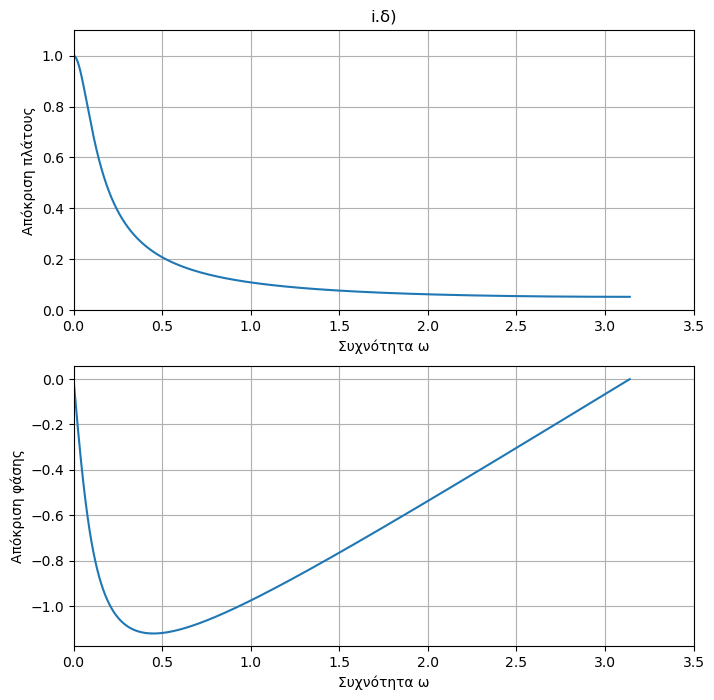

In [2]:
# i.δ)
a = 0.9
n = 2048

num1 = [1-a]        # βαθυπερατό 1ης τάξης
den1 = [1, -a]

W, H = sig.freqz(num1, den1, n)

plt.figure(figsize=(8,8))
plt.subplot(2,1,1)
plt.title('i.δ)')
plt.plot(W, abs(H))
plt.grid(True)
plt.xlim(0.0, 3.5)
plt.ylim(0, 1.1)
plt.ylabel('Απόκριση πλάτους')
plt.xlabel('Συχνότητα ω')

plt.subplot(2,1,2)
plt.plot(W, np.angle(H))
plt.grid(True)
plt.xlim(0.0, 3.5)
plt.ylabel('Απόκριση φάσης')
plt.xlabel('Συχνότητα ω')

plt.show()

ii. Θεωρήστε την παρακάτω εξίσωση διαφορών που περιγράφει ένα αιτιατό ΓΧΑ σύστημα:
$$y[n] = \frac{1+\alpha}{2}\big(x[n] - x[n-1]\big) + \alpha\, y[n-1], \: \: 0 < \alpha < 1$$

(α') Υπολογίστε στο χαρτί σας τη συνάρτηση μεταφοράς, $H(z)$, του παραπάνω συστήματος.

<u>**Απάντηση**</u>

Θα είναι:

$$Y(z) = \frac{1+\alpha}{2}\left(X(z) - X(z) z^{-1}\right) + \alpha Y(z) z^{-1} \Rightarrow Y(z)\left(1 - \alpha z^{-1}\right) = \frac{1+\alpha}{2}\left(1 - z^{-1}\right) X(z)$$

και άρα

$$H_{2}(z) = \frac{Y(z)}{X(z)} = \frac{1+\alpha}{2}\cdot\frac{1 - z^{-1}}{1 - \alpha z^{-1}}$$

με πόλο στο $z = \alpha$ (εντός του μοναδιαίου κύκλου) και μηδενικό στο $z = 1$. Για αιτιατό σύστημα, $ROC_{H_{2}}: |z| > \alpha$. Στο $\omega = 0$ ($z=1$) το κέρδος είναι $0$ (λόγω του μηδενικού στο $z=1$), ενώ στο $\omega = \pi$ ($z=-1$) το κέρδος είναι $\frac{1+\alpha}{2}\cdot\frac{2}{1+\alpha} = 1$: πρόκειται για **υψιπερατό** φίλτρο. Έτσι,

$$H_{2}(z) = \frac{1+\alpha}{2}\cdot\frac{1 - z^{-1}}{1 - \alpha z^{-1}}, \: |z|>\alpha$$

(β') Βρείτε στο χαρτί σας την κρουστική απόκριση $h[n]$.

<u>**Απάντηση**</u>

Γράφουμε τη συνάρτηση μεταφοράς ως άθροισμα δύο όρων:

$$H_{2}(z) = \frac{1+\alpha}{2}\left[\frac{1}{1 - \alpha z^{-1}} - \frac{z^{-1}}{1 - \alpha z^{-1}}\right]$$

Βάσει του ζεύγους $\dfrac{1}{1-\alpha z^{-1}} \overset{Z}{\longleftrightarrow} \alpha^{n} u[n]$ και της ιδιότητας της χρονικής ολίσθησης, προκύπτει:

$$h_{2}[n] = \frac{1+\alpha}{2}\Big(\alpha^{n} u[n] - \alpha^{n-1} u[n-1]\Big)$$

που ισοδύναμα γράφεται

$$h_{2}[n] = \frac{1+\alpha}{2}\,\delta[n] \; - \; \frac{1-\alpha^{2}}{2}\,\alpha^{n-1} u[n-1]$$

Επαληθεύεται ότι $\sum_{n} h_{2}[n] = 0$, δηλαδή μηδενικό κέρδος στο DC, όπως αναμένεται για υψιπερατό φίλτρο.

(γ') Υπολογίστε στο χαρτί σας την απόκριση σε συχνότητα, $H(e^{j\omega})$.

<u>**Απάντηση**</u>

Το πεδίο σύγκλισης $ROC_{H_{2}}: |z|>\alpha$ περιέχει τον μοναδιαίο κύκλο, άρα:

$$H_{2}(e^{j\omega}) = H_{2}(z) \Big|_{z = e^{j\omega}} \Longrightarrow H_{2}(e^{j\omega}) = \frac{1+\alpha}{2}\cdot\frac{1 - e^{-j\omega}}{1 - \alpha e^{-j\omega}}$$

Το μέτρο $|H_{2}(e^{j\omega})|$ ξεκινά από $0$ στο $\omega=0$ και αυξάνει μονότονα προς το $1$ στο $\omega=\pi$, επιβεβαιώνοντας τον υψιπερατό χαρακτήρα.

(δ') Βρείτε στην ``Python`` την απόκριση πλάτους και φάσης, με χρήση της συνάρτησης $\texttt{[H,W] = freqz(...)}$ σε $2048$ σημεία. Χρησιμοποιήστε τις συναρτήσεις $\texttt{plt.plot, abs, angle}$ κατά τα γνωστά. Θέστε $\alpha = 0.9$.

<u>**Απάντηση**</u>

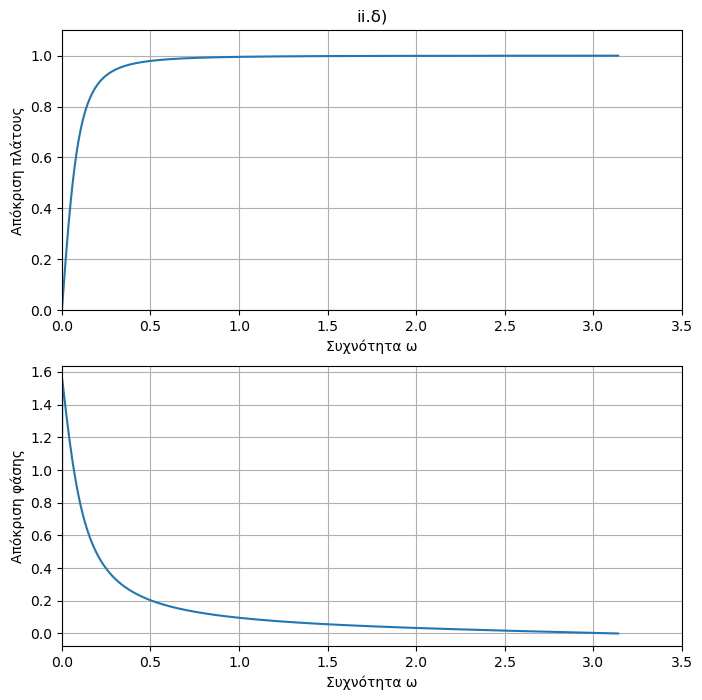

In [3]:
# ii.δ)
a = 0.9
n = 2048

num2 = [(1+a)/2, -(1+a)/2]    # υψιπερατό 1ης τάξης
den2 = [1, -a]

W, H = sig.freqz(num2, den2, n)

plt.figure(figsize=(8,8))
plt.subplot(2, 1, 1)
plt.title('ii.δ)')
plt.plot(W, abs(H))
plt.grid(True)
plt.xlim(0.0, 3.5)
plt.ylim(0, 1.1)
plt.ylabel('Απόκριση πλάτους')
plt.xlabel('Συχνότητα ω')

plt.subplot(2, 1, 2)
plt.plot(W, np.angle(H))
plt.grid(True)
plt.xlim(0.0, 3.5)
plt.ylabel('Απόκριση φάσης')
plt.xlabel('Συχνότητα ω')

plt.show()

iii. Φιλτράρετε το σήμα $\texttt{furelise.wav}$ που σας δίνεται με καθένα από τα παραπάνω συστήματα. Χρησιμοποιήστε την εντολή $\texttt{filter}$ για αυτό. Η παράμετρος θα είναι $\alpha = 0.9$. Ακούστε το αποτέλεσμα για κάθε σύστημα. Πώς θα χαρακτηρίζατε την επίδραση των συστημάτων στο σήμα εισόδου, βάσει του αποτελέσματος που ακούτε?

<u>**Απάντηση**</u>

Με $\alpha = 0.9$ και τα δύο φίλτρα αλλάζουν τη χροιά (τιμπρ) του ήχου, χωρίς να προσθέτουν ηχώ ή παραμόρφωση. Το **1ο σύστημα (βαθυπερατό)** αφήνει να περάσουν οι χαμηλές συχνότητες και εξασθενεί τις υψηλές: ο ήχος ακούγεται πιο "μουντός"/"πνιχτός", σαν να παίζει πίσω από έναν τοίχο ή κάτω από το νερό, αφού χάνεται η λαμπρότητα των υψηλών αρμονικών. Το **2ο σύστημα (υψιπερατό)** κάνει το αντίθετο: αφαιρεί τα μπάσα και αφήνει τις υψηλές συχνότητες, οπότε ο ήχος γίνεται "λεπτός"/"τσίγκινος" (thin/tinny), σαν μικρό ηχείο ή τηλέφωνο. Η επιλογή του $\alpha$ ελέγχει τη συχνότητα αποκοπής: τιμές πιο κοντά στο $1$ κάνουν το βαθυπερατό πιο επιθετικό (χαμηλότερη αποκοπή).

In [4]:
# iii.
fs, s = wavfile.read('./files/furelise.wav')

a = 0.9
num1 = [1-a];            den1 = [1, -a]          # βαθυπερατό
num2 = [(1+a)/2, -(1+a)/2]; den2 = [1, -a]       # υψιπερατό

# Φιλτράρισμα με το βαθυπερατό σύστημα
y1 = sig.lfilter(num1, den1, s)
Audio(y1, rate=fs)

In [5]:
# Φιλτράρισμα με το υψιπερατό σύστημα
y2 = sig.lfilter(num2, den2, s)
Audio(y2, rate=fs)

iv. Συνδυάστε τα δύο φίλτρα σε **σειρά** (διαδοχική εφαρμογή) ώστε να κατασκευάσετε ένα **ζωνοπερατό (bandpass)** φίλτρο. Υπολογίστε στο χαρτί σας τη συνολική συνάρτηση μεταφοράς και σχολιάστε γιατί η σειρά προκύπτει ζωνοπερατή. Έχει σημασία η σειρά εφαρμογής των δύο φίλτρων?

<u>**Απάντηση**</u>

Για να απομονώσουμε μια **μεσαία ζώνη** συχνοτήτων, εφαρμόζουμε ένα υψιπερατό (που κόβει τα μπάσα) με παράμετρο $\alpha_{H}$ και ένα βαθυπερατό (που κόβει τα πρίμα) με παράμετρο $\alpha_{L}$. Επειδή τα συστήματα είναι ΓΧΑ, η σύνδεση σε σειρά αντιστοιχεί σε **γινόμενο** των συναρτήσεων μεταφοράς:

$$H(z) = H_{L}(z)\, H_{H}(z) = \frac{1-\alpha_{L}}{1 - \alpha_{L} z^{-1}} \cdot \frac{1+\alpha_{H}}{2}\cdot\frac{1 - z^{-1}}{1 - \alpha_{H} z^{-1}}$$

Το συνολικό σύστημα έχει μηδενικά στα $z=0$ και $z=1$ και πόλους στα $z=\alpha_{L}$ και $z=\alpha_{H}$. Το μηδενικό στο $z=1$ μηδενίζει το κέρδος στο DC, ενώ ο πόλος του βαθυπερατού καταπιέζει τις πολύ υψηλές συχνότητες· έτσι επιβιώνει μόνο μια **ενδιάμεση ζώνη**, δηλαδή προκύπτει ζωνοπερατό φίλτρο. Επειδή ο πολλαπλασιασμός των $H(z)$ είναι αντιμεταθετικός (και τα συστήματα ΓΧΑ), **η σειρά εφαρμογής δεν έχει σημασία**: βαθυπερατό–μετά–υψιπερατό δίνει το ίδιο αποτέλεσμα με υψιπερατό–μετά–βαθυπερατό.

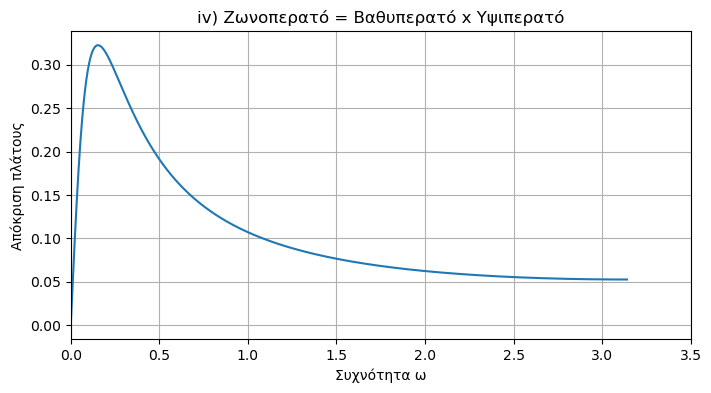

In [6]:
# iv. Ζωνοπερατό μέσω διαδοχικής εφαρμογής υψιπερατού και βαθυπερατού
n = 2048
aL = 0.9   # βαθυπερατό: ορίζει το πάνω άκρο της ζώνης
aH = 0.8   # υψιπερατό: ορίζει το κάτω άκρο της ζώνης

numL = [1-aL];              denL = [1, -aL]
numH = [(1+aH)/2, -(1+aH)/2]; denH = [1, -aH]

# Συνολική συνάρτηση μεταφοράς = γινόμενο των δύο (συνέλιξη αριθμητών / παρονομαστών)
num_bp = np.convolve(numL, numH)
den_bp = np.convolve(denL, denH)

W, H = sig.freqz(num_bp, den_bp, n)

plt.figure(figsize=(8,4))
plt.title('iv) Ζωνοπερατό = Βαθυπερατό x Υψιπερατό')
plt.plot(W, abs(H))
plt.grid(True)
plt.xlim(0.0, 3.5)
plt.ylabel('Απόκριση πλάτους')
plt.xlabel('Συχνότητα ω')
plt.show()

In [7]:
# Διαδοχικό φιλτράρισμα του σήματος: πρώτα υψιπερατό, μετά βαθυπερατό
y_hp = sig.lfilter(numH, denH, s)
y_bp = sig.lfilter(numL, denL, y_hp)
Audio(y_bp, rate=fs)

v. Μελετήστε πρακτικά την επίδραση της παραμέτρου $\alpha$ στη συχνότητα αποκοπής του **βαθυπερατού** φίλτρου. Σχεδιάστε την απόκριση πλάτους για διάφορες τιμές του $\alpha$ και φιλτράρετε το σήμα με μια πιο "ήπια" τιμή. **Σχολιάστε**.

<u>**Απάντηση**</u>

Όσο η παράμετρος $\alpha$ πλησιάζει το $1$, ο πόλος πλησιάζει τον μοναδιαίο κύκλο στο $z=1$ και η συχνότητα αποκοπής μετατοπίζεται προς τα **χαμηλά**: το φίλτρο γίνεται πιο επιθετικό βαθυπερατό και ο ήχος πιο πνιχτός. Για μικρότερες τιμές του $\alpha$ (π.χ. $\alpha=0.5$) η αποκοπή ανεβαίνει, περνούν περισσότερες υψηλές συχνότητες και η επίδραση στη χροιά είναι πιο διακριτική. Το παρακάτω διάγραμμα δείχνει ξεκάθαρα τη μετατόπιση της αποκοπής καθώς μεταβάλλεται το $\alpha$.

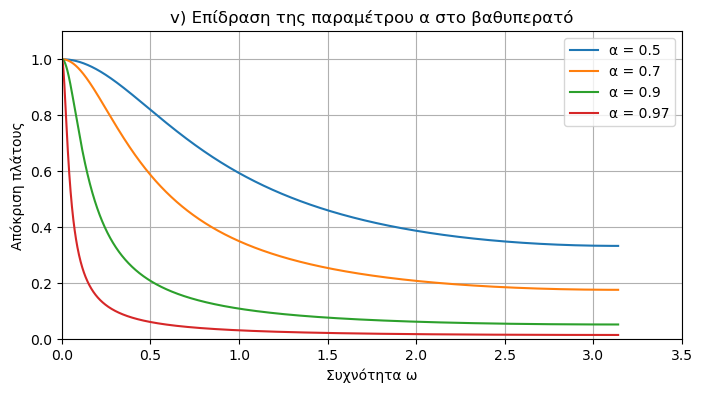

In [8]:
# v. Οικογένεια αποκρίσεων βαθυπερατού για διάφορα α
n = 2048
plt.figure(figsize=(8,4))
plt.title('v) Επίδραση της παραμέτρου α στο βαθυπερατό')
for a in [0.5, 0.7, 0.9, 0.97]:
    W, H = sig.freqz([1-a], [1, -a], n)
    plt.plot(W, abs(H), label=f'α = {a}')
plt.grid(True)
plt.xlim(0.0, 3.5)
plt.ylim(0, 1.1)
plt.ylabel('Απόκριση πλάτους')
plt.xlabel('Συχνότητα ω')
plt.legend()
plt.show()

In [9]:
# Ήπιο βαθυπερατό φιλτράρισμα (α = 0.5) και σύγκριση με το αρχικό σήμα
a = 0.5
y_soft = sig.lfilter([1-a], [1, -a], s)
Audio(y_soft, rate=fs)

In [10]:
# Αρχικό σήμα
Audio(s, rate=fs)

---
---